In [49]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [50]:
df = sns.load_dataset("titanic")

In [51]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [52]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [54]:
df.drop(['deck','embark_town','alive','class','who','adult_male'],axis=1,inplace=True)

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
 8   alone     891 non-null    bool   
dtypes: bool(1), float64(2), int64(4), object(2)
memory usage: 56.7+ KB


In [56]:
df['age'].fillna(df['age'].mean(),inplace=True)

In [57]:
df.dropna(subset=["embarked"],inplace=True) #completly deletes the row from the dataset, where the null value exists

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  889 non-null    int64  
 1   pclass    889 non-null    int64  
 2   sex       889 non-null    object 
 3   age       889 non-null    float64
 4   sibsp     889 non-null    int64  
 5   parch     889 non-null    int64  
 6   fare      889 non-null    float64
 7   embarked  889 non-null    object 
 8   alone     889 non-null    bool   
dtypes: bool(1), float64(2), int64(4), object(2)
memory usage: 63.4+ KB


In [59]:
# Label Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
columns = ['sex','embarked']
for col in columns:
  df[col] = le.fit_transform(df[col])

# else , we can do this instead of specific row df['sex'] = le.fit_transform(df['sex])
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,1,22.0,1,0,7.2500,2,False
1,1,1,0,38.0,1,0,71.2833,0,False
2,1,3,0,26.0,0,0,7.9250,2,True
3,1,1,0,35.0,1,0,53.1000,2,False
4,0,3,1,35.0,0,0,8.0500,2,True


In [60]:
df = df.astype(int)
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,1,22,1,0,7,2,0
1,1,1,0,38,1,0,71,0,0
2,1,3,0,26,0,0,7,2,1
3,1,1,0,35,1,0,53,2,0
4,0,3,1,35,0,0,8,2,1


In [61]:
# Logistic Regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

model = LogisticRegression()
X = df.drop('survived',axis=1) #feature
y = df['survived']  #target

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

print("Accuracy Score: ",accuracy_score(y_test,y_pred))
print("Confusion_matrix: ",confusion_matrix(y_test,y_pred))



Accuracy Score:  0.8033707865168539
Confusion_matrix:  [[90 19]
 [16 53]]


In [62]:
# classification report includes recall_score, precision_score and f1_score
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.85      0.83      0.84       109
           1       0.74      0.77      0.75        69

    accuracy                           0.80       178
   macro avg       0.79      0.80      0.79       178
weighted avg       0.81      0.80      0.80       178



In [63]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)


In [64]:
# KNN
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled,y_train)
knn_pred = knn.predict(X_test_scaled)

print("Accuracy Score: ",accuracy_score(y_test,knn_pred))
print("Confusion Matrix ",confusion_matrix(y_test,knn_pred))
print("Classifiaction report")
print(classification_report(y_test,knn_pred))

Accuracy Score:  0.7752808988764045
Confusion Matrix  [[89 20]
 [20 49]]
Classifiaction report
              precision    recall  f1-score   support

           0       0.82      0.82      0.82       109
           1       0.71      0.71      0.71        69

    accuracy                           0.78       178
   macro avg       0.76      0.76      0.76       178
weighted avg       0.78      0.78      0.78       178



In [65]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train,y_train)
y_nb = nb.predict(X_test)

print("Accuracy Score: ",accuracy_score(y_test,y_nb))
print("Confusion Matrix ",confusion_matrix(y_test,y_nb))
print("Classification Report")
print(classification_report(y_test,y_nb))


Accuracy Score:  0.7752808988764045
Confusion Matrix  [[84 25]
 [15 54]]
Classification Report
              precision    recall  f1-score   support

           0       0.85      0.77      0.81       109
           1       0.68      0.78      0.73        69

    accuracy                           0.78       178
   macro avg       0.77      0.78      0.77       178
weighted avg       0.78      0.78      0.78       178



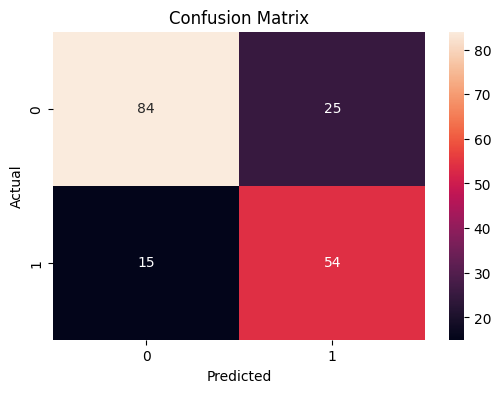

In [66]:
# visualization of the confusion matrix for the naive bayes theorem
cm = confusion_matrix(y_test,y_nb)
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Accuracy Score:  0.8202247191011236
Confusion Matrix  [[92 17]
 [15 54]]
Classification Report
              precision    recall  f1-score   support

           0       0.86      0.84      0.85       109
           1       0.76      0.78      0.77        69

    accuracy                           0.82       178
   macro avg       0.81      0.81      0.81       178
weighted avg       0.82      0.82      0.82       178



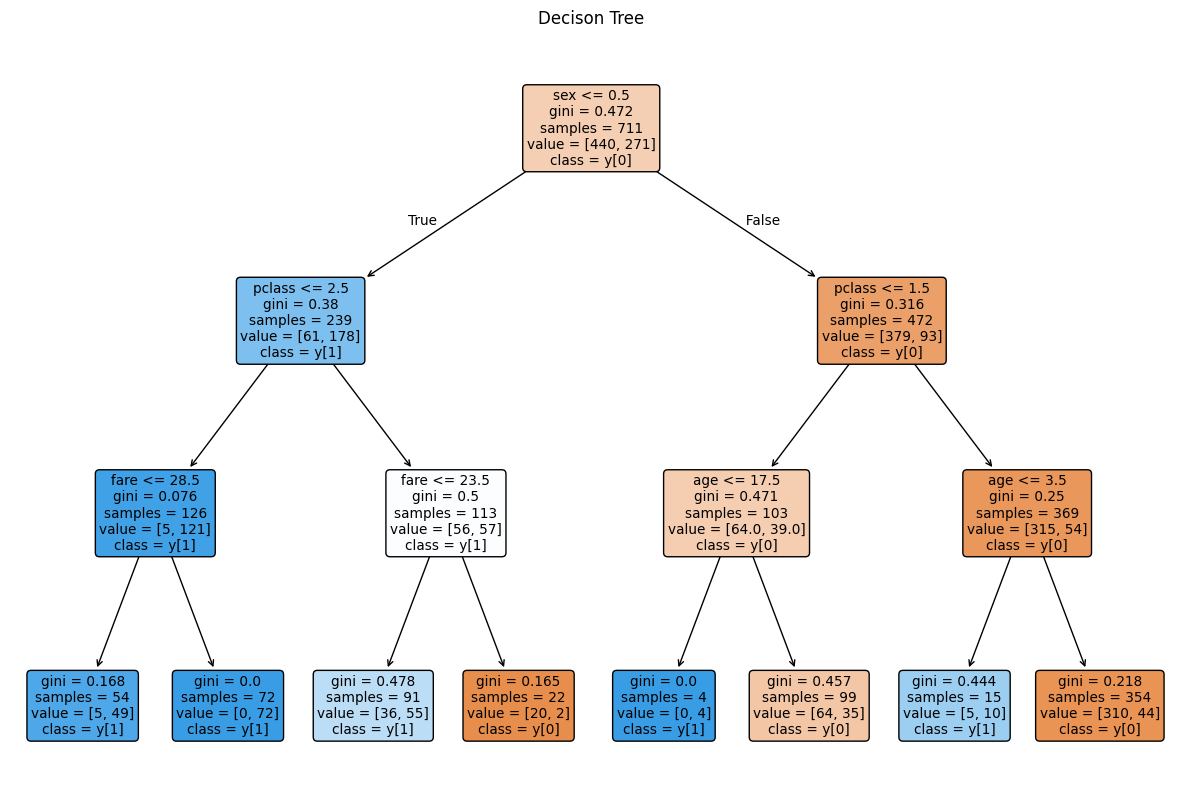

In [67]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
dt = DecisionTreeClassifier(random_state=42,max_depth=3)
#here the random_state is included for the better performance
#feature scaling is not required in the decison tree
dt.fit(X_train,y_train)
y_dt = dt.predict(X_test)

print("Accuracy Score: ",accuracy_score(y_test,y_dt))
print("Confusion Matrix ",confusion_matrix(y_test,y_dt))
print("Classification Report")
print(classification_report(y_test,y_dt))

plt.figure(figsize=(15,10))
plot_tree(dt,feature_names=X.columns,class_names=True,filled=True,rounded=True)
plt.title("Decison Tree")
plt.show()

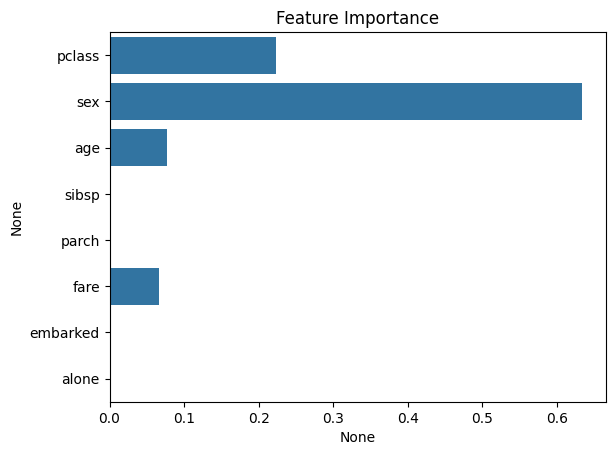

In [68]:
# Feature importance Visualization
importance = pd.Series(dt.feature_importances_,index = X.columns)
sns.barplot(x=importance, y=importance.index)
plt.title("Feature Importance")
plt.show()

In [69]:
# Support Vec  tor Classification
from sklearn.svm import SVC
svm = SVC(kernel='rbf') #defualt kernel
svm.fit(X_train_scaled,y_train)
y_svm = svm.predict(X_test_scaled)
# it requires feature scaling
print("Accuracy Score: ",accuracy_score(y_test,y_svm))
print("Confusion Matrix ",confusion_matrix(y_test,y_svm))


Accuracy Score:  0.8258426966292135
Confusion Matrix  [[96 13]
 [18 51]]


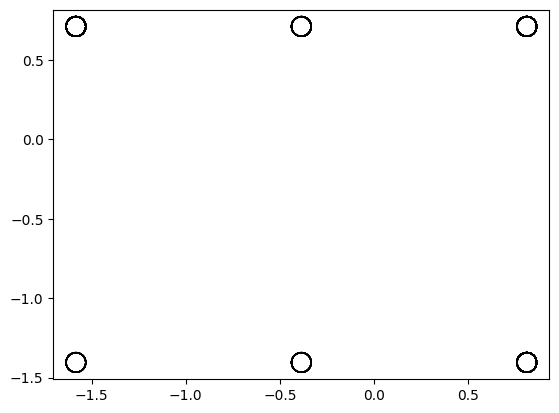

In [70]:
plt.scatter(svm.support_vectors_[:,0],svm.support_vectors_[:,1],s=200,facecolors='none',edgecolors='k')